# Ensemble Kalman Filter from Scratch

This notebook builds an **Ensemble Kalman Filter (EnKF)** step by step,
using gaussx ensemble primitives on the chaotic Lorenz-63 system.

**What you'll learn:**

1. Computing empirical covariance as a structured `LowRankUpdate` operator
   with `gaussx.ensemble_covariance`
2. Computing cross-covariance between state and observation ensembles
   with `gaussx.ensemble_cross_covariance`
3. Numerically stable covariance updates with `gaussx.joseph_update`
4. Deriving process noise from a stationary covariance with
   `gaussx.process_noise_covariance`

## Background

The **Ensemble Kalman Filter** (Evensen, 1994) is a Monte Carlo
approximation to the Kalman filter designed for high-dimensional,
nonlinear systems. Instead of propagating a mean and covariance matrix
explicitly, it maintains an *ensemble* of $J$ particles
$\{x^{(j)}\}_{j=1}^{J}$ that collectively represent the state
distribution.

The key idea: at each step the forecast covariance is estimated
*empirically* from the ensemble spread, so no linearization (tangent
linear model) is needed. The update step then applies the standard
Kalman gain formula using these empirical statistics.

### EnKF algorithm sketch

**Forecast:**
Propagate each particle through the (possibly nonlinear) dynamics
$x^{(j)}_{t|t-1} = f(x^{(j)}_{t-1|t-1}) + q^{(j)}_t$.

**Analysis:**

1. Compute ensemble covariance:
   $\hat{P} = \frac{1}{J}\sum_j (x^{(j)} - \bar{x})(x^{(j)} - \bar{x})^\top$
2. Compute cross-covariance between state and predicted observations:
   $C_{xy} = \frac{1}{J}\sum_j (x^{(j)} - \bar{x})(y^{(j)} - \bar{y})^\top$
3. Compute innovation covariance:
   $C_{yy} = \frac{1}{J}\sum_j (y^{(j)} - \bar{y})(y^{(j)} - \bar{y})^\top + R$
4. Kalman gain: $K = C_{xy} \, C_{yy}^{-1}$
5. Perturbed-observation update:
   $x^{(j)}_{t|t} = x^{(j)}_{t|t-1} + K(y_t + \epsilon^{(j)} - H x^{(j)}_{t|t-1})$

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Define the Lorenz-63 system

The Lorenz-63 system is a classic chaotic dynamical system:

$$\frac{dx}{dt} = \sigma(y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

With the standard parameters $\sigma = 10$, $\rho = 28$, $\beta = 8/3$,
the system exhibits the famous butterfly attractor.
We discretize with a 4th-order Runge-Kutta integrator.

In [2]:
# Lorenz-63 parameters
sigma_l = 10.0
rho = 28.0
beta = 8.0 / 3.0
dt = 0.01


def lorenz63(state):
    """Lorenz-63 right-hand side."""
    x, y, z = state[0], state[1], state[2]
    dx = sigma_l * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return jnp.array([dx, dy, dz])


def rk4_step(state, _dt=dt):
    """Single RK4 integration step."""
    k1 = lorenz63(state)
    k2 = lorenz63(state + 0.5 * _dt * k1)
    k3 = lorenz63(state + 0.5 * _dt * k2)
    k4 = lorenz63(state + _dt * k3)
    return state + (_dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Quick sanity check: integrate a short trajectory
x_test = jnp.array([1.0, 1.0, 1.0])
x_test_next = rk4_step(x_test)
print("One RK4 step: ", x_test, " -> ", x_test_next)

One RK4 step:  [1. 1. 1.]  ->  [1.01256719 1.2599178  0.98489097]


## Generate the true trajectory and observations

We observe only the $x$ and $y$ components of the Lorenz state with
additive Gaussian noise. The $z$ component must be inferred.

In [3]:
T = 500  # number of time steps
obs_noise_std = 2.0

# Observation model: observe x and y only
H = jnp.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
R = obs_noise_std**2 * jnp.eye(2)

# True initial condition (on the attractor)
x_true_0 = jnp.array([1.508, -1.531, 25.46])

key = jax.random.PRNGKey(42)


def generate_truth(carry, key_t):
    """Propagate true state and generate noisy observation."""
    x_true = carry
    x_true_next = rk4_step(x_true)
    noise = obs_noise_std * jax.random.normal(key_t, shape=(2,))
    y_t = H @ x_true_next + noise
    return x_true_next, (x_true_next, y_t)


keys_truth = jax.random.split(key, T)
_, (true_states, observations) = jax.lax.scan(generate_truth, x_true_0, keys_truth)

times = jnp.arange(T) * dt
print("True trajectory shape:", true_states.shape)
print("Observations shape:", observations.shape)

True trajectory shape: (500, 3)
Observations shape: (500, 2)


## Initialize the ensemble

We draw $J = 50$ particles from a Gaussian centered at the true initial
state with moderate uncertainty. In practice the initial ensemble
would come from a climatological prior.

In [4]:
J = 50  # ensemble size
d = 3  # state dimension

P0 = jnp.diag(jnp.array([2.0, 2.0, 2.0]))

key, subkey = jax.random.split(key)
L0 = jnp.linalg.cholesky(P0)
ensemble = x_true_0[None, :] + jax.random.normal(subkey, shape=(J, d)) @ L0.T

print("Initial ensemble shape:", ensemble.shape)
print("Ensemble mean:", jnp.mean(ensemble, axis=0))

Initial ensemble shape: (50, 3)
Ensemble mean: [ 1.80543028 -1.45576339 25.35649402]


## Inspect the ensemble covariance operator

Before running the filter, let's see what `gaussx.ensemble_covariance`
returns. It produces a `LowRankUpdate` operator -- a structured
representation of $\hat{P} = (1/J)\sum_j \delta_j \delta_j^\top$
where $\delta_j = x^{(j)} - \bar{x}$. This is rank $\leq J$ and
avoids materializing the full $d \times d$ matrix (crucial when $d$
is large).

In [5]:
P_ens = gaussx.ensemble_covariance(ensemble)
print("Type:", type(P_ens).__name__)
print("Materialized covariance:\n", P_ens.as_matrix())

# Compare with naive computation
mean_ens = jnp.mean(ensemble, axis=0)
devs = ensemble - mean_ens[None, :]
P_naive = (devs.T @ devs) / J
print("\nNaive covariance:\n", P_naive)
print("Max difference:", jnp.max(jnp.abs(P_ens.as_matrix() - P_naive)))

Type: LowRankUpdate


Materialized covariance:
 [[ 1.89403362  0.18874692 -0.22508983]
 [ 0.18874692  1.90614772 -0.60569166]
 [-0.22508983 -0.60569166  2.1204657 ]]

Naive covariance:
 [[ 1.89403362  0.18874692 -0.22508983]
 [ 0.18874692  1.90614772 -0.60569166]
 [-0.22508983 -0.60569166  2.1204657 ]]
Max difference: 8.881784197001252e-16


## Run the Ensemble Kalman Filter

The main loop: forecast each particle through the nonlinear Lorenz
dynamics, then perform the EnKF analysis update using gaussx ensemble
primitives.

We add a small amount of process noise (additive inflation) to prevent
ensemble collapse, a common practical technique.

In [6]:
process_noise_std = 0.1
Q_enkf = process_noise_std**2 * jnp.eye(d)


def enkf_step(carry, inputs):
    """Single EnKF forecast + analysis step."""
    ensemble_prev, _key_prev = carry
    y_obs, key_t = inputs

    k1, k2, k3 = jax.random.split(key_t, 3)

    # --- Forecast: propagate each particle through nonlinear dynamics ---
    ensemble_pred = jax.vmap(rk4_step)(ensemble_prev)

    # Add process noise (additive inflation)
    q_noise = process_noise_std * jax.random.normal(k1, shape=(J, d))
    ensemble_pred = ensemble_pred + q_noise

    # --- Analysis: compute ensemble statistics using gaussx ---

    # Predicted observation ensemble: y_j = H @ x_j
    obs_pred = ensemble_pred @ H.T  # (J, 2)

    # Cross-covariance C_xy between state and predicted observations
    C_xy = gaussx.ensemble_cross_covariance(ensemble_pred, obs_pred)  # (3, 2)

    # Innovation covariance C_yy + R
    C_yy_op = gaussx.ensemble_covariance(obs_pred)
    C_yy = C_yy_op.as_matrix() + R  # (2, 2)

    # Kalman gain K = C_xy @ inv(C_yy)
    K = C_xy @ jnp.linalg.inv(C_yy)  # (3, 2)

    # Perturbed-observation update
    obs_noise = obs_noise_std * jax.random.normal(k2, shape=(J, 2))
    innovations = y_obs[None, :] + obs_noise - obs_pred  # (J, 2)
    ensemble_upd = ensemble_pred + innovations @ K.T  # (J, 3)

    # Ensemble mean for diagnostics
    mean_upd = jnp.mean(ensemble_upd, axis=0)

    return (ensemble_upd, k3), (mean_upd, ensemble_upd)


# Prepare inputs
keys_enkf = jax.random.split(jax.random.PRNGKey(123), T)
inputs = (observations, keys_enkf)

# Run the filter
init_carry = (ensemble, jax.random.PRNGKey(0))
_, (enkf_means, enkf_ensembles) = jax.lax.scan(enkf_step, init_carry, inputs)

print("EnKF means shape:", enkf_means.shape)
print("EnKF ensembles shape:", enkf_ensembles.shape)

EnKF means shape: (500, 3)
EnKF ensembles shape: (500, 50, 3)


## Joseph-form covariance update

The standard EnKF implicitly updates the covariance via the ensemble.
For diagnostics or hybrid filters, one sometimes needs the *explicit*
updated covariance. The Joseph form

$$P_{\text{upd}} = (I - KH)\,P_{\text{pred}}\,(I - KH)^\top + K R K^\top$$

is numerically more stable than the naive $(I - KH) P_{\text{pred}}$
formula. Let's demonstrate `gaussx.joseph_update` on the final step.

In [7]:
# Use the final forecast ensemble to get P_pred
final_ensemble_pred = jax.vmap(rk4_step)(enkf_ensembles[-1])
P_pred_op = gaussx.ensemble_covariance(final_ensemble_pred)
P_pred = P_pred_op.as_matrix()

# Recompute the Kalman gain for this step
obs_pred_final = final_ensemble_pred @ H.T
C_xy_final = gaussx.ensemble_cross_covariance(final_ensemble_pred, obs_pred_final)
C_yy_final = gaussx.ensemble_covariance(obs_pred_final).as_matrix() + R
K_final = C_xy_final @ jnp.linalg.inv(C_yy_final)

# Joseph-form update
P_upd_joseph = gaussx.joseph_update(P_pred, K_final, H, R)

# Compare with naive formula
I_KH = jnp.eye(d) - K_final @ H
P_upd_naive = I_KH @ P_pred

print("Joseph-form updated covariance:\n", P_upd_joseph)
print("\nNaive updated covariance:\n", P_upd_naive)
print("\nJoseph form is symmetric:", jnp.allclose(P_upd_joseph, P_upd_joseph.T))

Joseph-form updated covariance:
 [[ 0.14559597  0.23077515  0.00331839]
 [ 0.23077515  0.44376559 -0.01157417]
 [ 0.00331839 -0.01157417  0.16298755]]

Naive updated covariance:
 [[ 0.14559597  0.23077515  0.00331839]
 [ 0.23077515  0.44376559 -0.01157417]
 [ 0.00331839 -0.01157417  0.16298755]]

Joseph form is symmetric: True


## Process noise from stationary covariance

For a *linearized* version of the Lorenz system, we can compute the
Jacobian at a fixed point and use `gaussx.process_noise_covariance`
to derive the process noise $Q$ that is consistent with a given
stationary covariance $P_\infty$:

$$Q = P_\infty - A \, P_\infty \, A^\top$$

This is useful when you know the long-run statistics but need the
step-to-step noise for a filter.

In [8]:
# Jacobian of the Lorenz system at the origin (one of three fixed points)
# For x=y=z=0: dF/dx = [[-sigma, sigma, 0], [rho, -1, 0], [0, 0, -beta]]
F_lin = jnp.array([[-sigma_l, sigma_l, 0.0], [rho, -1.0, 0.0], [0.0, 0.0, -beta]])

# Discretize the linearized system (first-order: A ~ I + dt*F)
A_lin = jnp.eye(d) + dt * F_lin
print("Linearized transition A:\n", A_lin)

# Choose a stationary covariance (e.g., from long-run ensemble statistics)
Pinf = jnp.cov(true_states.T)
print("\nEmpirical stationary covariance Pinf:\n", Pinf)

# Compute the implied process noise
Q_implied = gaussx.process_noise_covariance(A_lin, Pinf)
print("\nImplied process noise Q:\n", Q_implied)
print("Q is symmetric:", jnp.allclose(Q_implied, Q_implied.T))

Linearized transition A:
 [[0.9        0.1        0.        ]
 [0.28       0.99       0.        ]
 [0.         0.         0.97333333]]



Empirical stationary covariance Pinf:
 [[57.3357036  57.32115367 -0.2265445 ]
 [57.32115367 77.09044449  1.01167262]
 [-0.2265445   1.01167262 79.84132981]]

Implied process noise Q:
 [[ -0.19492842 -17.43753787  -0.12656099]
 [-17.43753787 -34.73986691   0.09856581]
 [ -0.12656099   0.09856581   4.2014282 ]]
Q is symmetric: True


## Plot: 3D Lorenz attractor

The true trajectory, ensemble mean estimate, and ensemble spread
projected onto the Lorenz attractor.

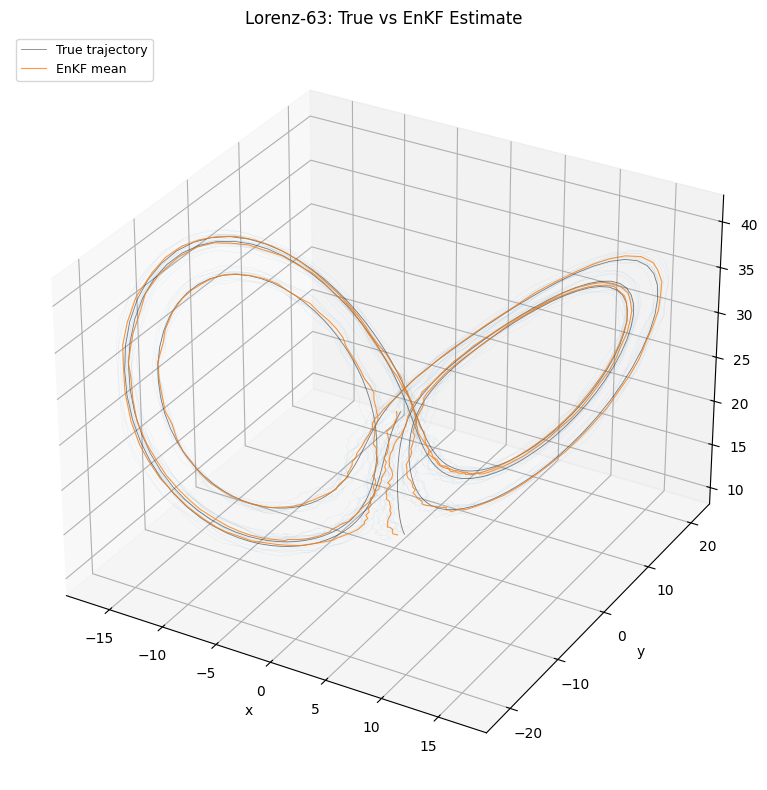

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    true_states[:, 0],
    true_states[:, 1],
    true_states[:, 2],
    "k-",
    lw=0.6,
    alpha=0.5,
    label="True trajectory",
)
ax.plot(
    enkf_means[:, 0],
    enkf_means[:, 1],
    enkf_means[:, 2],
    "C1-",
    lw=0.8,
    alpha=0.8,
    label="EnKF mean",
)

# Plot a few ensemble members at the final time
for j in range(min(10, J)):
    traj_j = enkf_ensembles[:, j, :]
    ax.plot(
        traj_j[:, 0],
        traj_j[:, 1],
        traj_j[:, 2],
        "C0-",
        lw=0.2,
        alpha=0.15,
    )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz-63: True vs EnKF Estimate")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, which="major", alpha=0.3)
plt.tight_layout()
plt.show()

## Plot: time series with ensemble spread

Each state component over time, showing the true value, ensemble mean,
and $\pm 2\sigma$ spread computed from the ensemble.

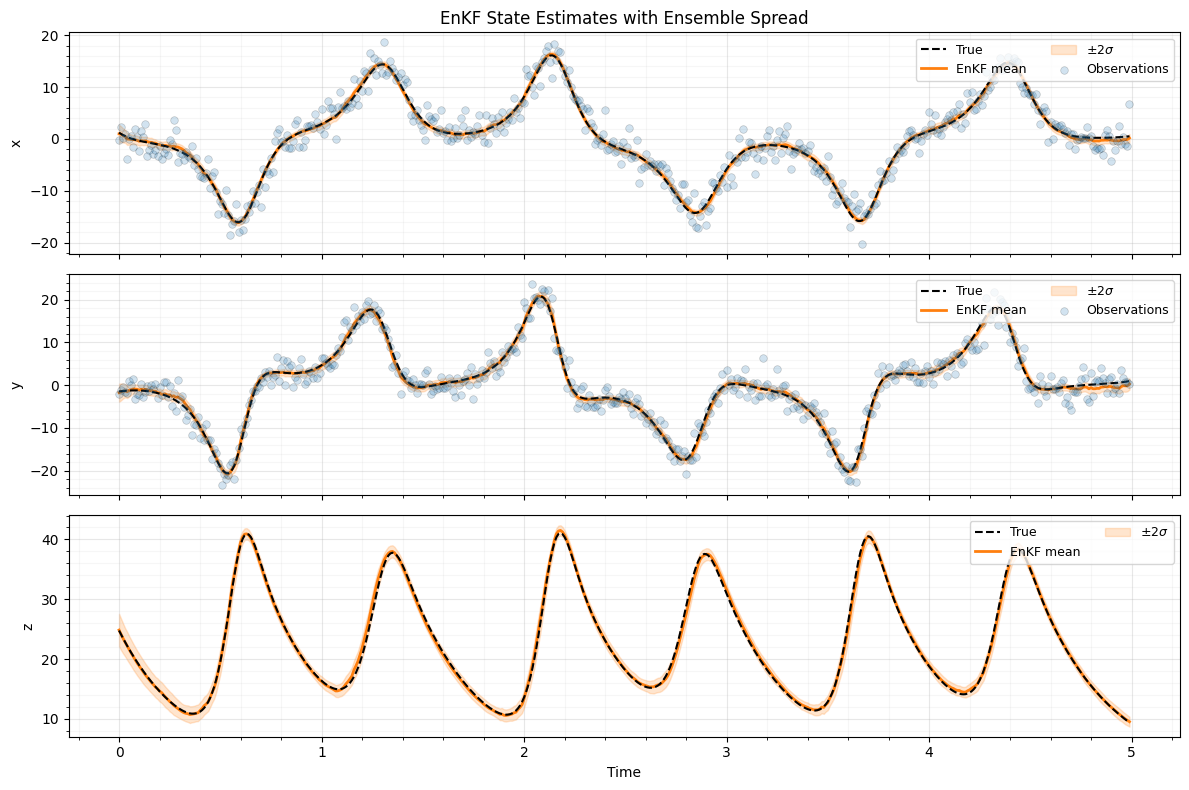

In [10]:
# Compute ensemble standard deviation at each time step
enkf_std = jnp.std(enkf_ensembles, axis=1)  # (T, 3)

labels = ["x", "y", "z"]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, (ax, label) in enumerate(zip(axes, labels, strict=True)):
    ax.plot(times, true_states[:, i], "k--", lw=1.5, label="True", zorder=4)
    ax.plot(times, enkf_means[:, i], "C1-", lw=2, label="EnKF mean", zorder=3)
    ax.fill_between(
        times,
        enkf_means[:, i] - 2 * enkf_std[:, i],
        enkf_means[:, i] + 2 * enkf_std[:, i],
        color="C1",
        alpha=0.2,
        label=r"$\pm 2\sigma$",
    )
    if i < 2:
        ax.scatter(
            times,
            observations[:, i],
            s=30,
            c="C0",
            edgecolors="k",
            linewidths=0.5,
            alpha=0.2,
            label="Observations",
            zorder=5,
        )
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=9, ncol=2)
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
    ax.minorticks_on()

axes[-1].set_xlabel("Time")
axes[0].set_title("EnKF State Estimates with Ensemble Spread")
plt.tight_layout()
plt.show()

## Plot: RMSE over time

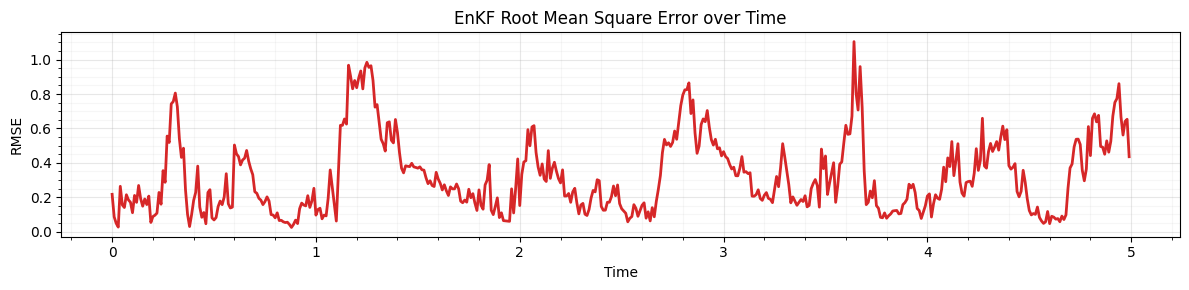

Mean RMSE: 0.320
Final RMSE: 0.435


In [11]:
rmse = jnp.sqrt(jnp.mean((enkf_means - true_states) ** 2, axis=1))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(times, rmse, "C3-", lw=2)
ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("EnKF Root Mean Square Error over Time")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

print(f"Mean RMSE: {jnp.mean(rmse):.3f}")
print(f"Final RMSE: {rmse[-1]:.3f}")

## Summary

- **`gaussx.ensemble_covariance(particles)`** returns a `LowRankUpdate`
  operator representing the empirical covariance. This structured
  representation avoids materializing a full $d \times d$ matrix and
  enables efficient Woodbury-based solves when the ensemble size
  $J \ll d$.

- **`gaussx.ensemble_cross_covariance(particles_theta, particles_G)`**
  computes the cross-covariance matrix between two ensembles, giving
  the $(d_1, d_2)$ array needed for the Kalman gain.

- **`gaussx.joseph_update(P_pred, K, H, R)`** provides the numerically
  stable Joseph-form covariance update, guaranteeing symmetry even
  when the Kalman gain is approximate.

- **`gaussx.process_noise_covariance(A, Pinf)`** derives the process
  noise $Q = P_\infty - A P_\infty A^\top$ from a stationary covariance,
  useful when calibrating a filter from long-run statistics.

Together these primitives let you build ensemble Kalman methods that
are fully compatible with JAX transforms (`jit`, `vmap`, `grad`)
while preserving structured linear algebra where it matters.

## References

- Evensen, G. (1994). Sequential data assimilation with a nonlinear
  quasi-geostrophic model using Monte Carlo methods to forecast error
  statistics. *J. Geophys. Res.*, 99(C5), 10143--10162.
- Lorenz, E. N. (1963). Deterministic nonperiodic flow.
  *J. Atmos. Sci.*, 20(2), 130--141.
- Bucy, R. S. & Joseph, P. D. (1968). *Filtering for Stochastic
  Processes with Applications to Guidance*. Interscience.
- Sarkka, S. (2013). *Bayesian Filtering and Smoothing*. Cambridge
  University Press.